## Data Import and Cleaning:

In [82]:
import numpy as np
import pandas as pd

df = pd.read_csv('global_power_plant_database.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

C:\Users\avigd\AppData\Local\Temp\ipykernel_23756\2708713931.py:4: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('global_power_plant_database.csv')


In [83]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [84]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_g

In [85]:
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.notna().sum() > 0 and converted.notna().sum() >= df[col].notna().sum() * 0.9:
        df[col] = converted.astype(np.float64)

## Exploratory Data Analysis:

In [86]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,1.614400e+04,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,6.834034e+05,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,4.893219e+05,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,1.217100e+04,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,5.561450e+04,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,1.021085e+06,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,1.066890e+06,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,1.118187e+06,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [87]:
df.mean(numeric_only=True)

capacity_mw                         163.355148
latitude                             32.816637
longitude                            -6.972803
commissioning_year                 1997.414823
wepp_id                          683403.407953
year_of_capacity_data              2018.218849
generation_gwh_2013                 592.696107
generation_gwh_2014                 656.863891
generation_gwh_2015                 762.368840
generation_gwh_2016                 693.149763
generation_gwh_2017                 661.834161
generation_gwh_2018                 517.320785
generation_gwh_2019                 423.922436
estimated_generation_gwh_2013       239.112221
estimated_generation_gwh_2014       242.431122
estimated_generation_gwh_2015       235.866067
estimated_generation_gwh_2016       235.695265
estimated_generation_gwh_2017       716.443378
dtype: float64

In [88]:
df.median(numeric_only=True)

capacity_mw                      1.674500e+01
latitude                         3.972775e+01
longitude                       -2.127100e+00
commissioning_year               2.007000e+03
wepp_id                          1.021085e+06
year_of_capacity_data            2.019000e+03
generation_gwh_2013              2.342600e+01
generation_gwh_2014              2.360850e+01
generation_gwh_2015              2.614200e+01
generation_gwh_2016              2.246239e+01
generation_gwh_2017              1.787650e+01
generation_gwh_2018              1.253000e+01
generation_gwh_2019              1.153000e+01
estimated_generation_gwh_2013    2.762000e+01
estimated_generation_gwh_2014    2.825000e+01
estimated_generation_gwh_2015    2.683000e+01
estimated_generation_gwh_2016    2.755500e+01
estimated_generation_gwh_2017    3.759000e+01
dtype: float64

In [89]:
df.std(numeric_only=True)

capacity_mw                         489.636072
latitude                             22.638603
longitude                            78.405850
commissioning_year                   23.397835
wepp_id                          489321.859670
year_of_capacity_data                 1.606428
generation_gwh_2013                2174.833482
generation_gwh_2014                2231.464288
generation_gwh_2015                2533.459828
generation_gwh_2016                2404.516759
generation_gwh_2017                2369.296957
generation_gwh_2018                1975.302686
generation_gwh_2019                1698.506485
estimated_generation_gwh_2013      1191.258172
estimated_generation_gwh_2014      1285.798297
estimated_generation_gwh_2015      1267.005223
estimated_generation_gwh_2016      1259.559841
estimated_generation_gwh_2017      2484.361200
dtype: float64

Explore the distribution of power plants by country and fuel type.

In [90]:
df.groupby('country').count()['name']

country
AFG      9
AGO     14
ALB      8
ARE     30
ARG    236
      ... 
VNM    236
YEM      7
ZAF    104
ZMB     15
ZWE      2
Name: name, Length: 167, dtype: int64

In [91]:
df.groupby('primary_fuel').count()['name']

primary_fuel
Biomass            1430
Coal               2330
Cogeneration         41
Gas                3998
Geothermal          189
Hydro              7156
Nuclear             195
Oil                2320
Other                43
Petcoke              12
Solar             10665
Storage             135
Waste              1068
Wave and Tidal       10
Wind               5344
Name: name, dtype: int64

## Statistical Analysis:

In [92]:
# df.columns

df.groupby('primary_fuel')['capacity_mw'].agg([
    ('mean', np.mean),
    ('median', np.median),
    ('std', np.std),
    ('min', np.min),
    ('max', np.max),
])

,mean,median,std,min,max
primary_fuel,,,,,
Biomass,23.972938,9.45000,39.448004,1.0,528.00
Coal,843.579828,600.00000,887.996568,1.2,7000.00
Cogeneration,98.731707,31.90000,279.950473,1.6,1404.00
Gas,373.449375,147.50000,560.863990,1.0,8865.00
Geothermal,67.130952,30.00000,114.337205,1.0,1163.00
Hydro,147.171551,20.00000,549.770911,1.0,22500.00
Nuclear,2091.855179,1888.00000,1300.162646,20.0,8212.00
Oil,112.878754,9.00000,391.924545,1.0,6794.00
Other,84.020000,40.00000,144.185002,4.5,845.26


Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.

- H0 : mean of capacity_mw =  every fuels
- H1: at least one type of fuel with a different average

In [ ]:
from scipy import stats

def mean_pow_diff(fuel1, fuel2):
    fuel1 = df.loc[df['primary_fuel'] == fuel1, 'capacity_mw'].dropna().to_numpy()
    fuel2 = df.loc[df['primary_fuel'] == fuel2, 'capacity_mw'].dropna().to_numpy()

    t_statistic, p_value = stats.ttest_ind(fuel1, fuel2)

    alpha = 0.05
    print("t-statistic:", t_statistic)
    print("p-value:", p_value)

    if p_value < alpha:
        print("Reject the null hypothesis")
    else:
        print("Fail to reject the null hypothesis")

fuels = df['primary_fuel'].unique()
for i in range(len(fuels)):
    for j in range(i + 1, len(fuels)):
        print(f"\n--- {fuels[i]} - {fuels[j]} ---")
        mean_pow_diff(fuels[i], fuels[j])


--- Hydro - Solar ---
t-statistic: 24.222429575549526
p-value: 1.4814019178500114e-127
Reject the null hypothesis

--- Hydro - Gas ---
t-statistic: -20.6924927358989
p-value: 2.2691929381794756e-93
Reject the null hypothesis

--- Hydro - Other ---
t-statistic: 0.7529851772876857
p-value: 0.45148345041701676
Fail to reject the null hypothesis

--- Hydro - Oil ---
t-statistic: 2.7835598840896365
p-value: 0.005387248989556673
Reject the null hypothesis

--- Hydro - Wind ---
t-statistic: 12.845450282869932
p-value: 1.5754108797906702e-37
Reject the null hypothesis

--- Hydro - Nuclear ---
t-statistic: -46.00690898596078
p-value: 0.0
Reject the null hypothesis

--- Hydro - Coal ---
t-statistic: -44.95639460067933
p-value: 0.0
Reject the null hypothesis

--- Hydro - Waste ---
t-statistic: 7.925696390668839
p-value: 2.5660416654757745e-15
Reject the null hypothesis

--- Hydro - Biomass ---
t-statistic: 8.468728211061388
p-value: 2.8913313720572646e-17
Reject the null hypothesis

--- Hydro - 

## Time Series Analysis:

In [104]:
import numpy as np

years = df['commissioning_year'].dropna().to_numpy()
unique_years, counts = np.unique(years, return_counts=True)

for i in range(len(unique_years)):
    year = unique_years[i]
    count = counts[i]
    print(f"{int(year)}: {count} centrales")

1896: 1 centrales
1899: 1 centrales
1900: 6 centrales
1901: 2 centrales
1902: 4 centrales
1903: 4 centrales
1903: 1 centrales
1903: 1 centrales
1904: 3 centrales
1905: 8 centrales
1905: 1 centrales
1906: 5 centrales
1906: 1 centrales
1906: 1 centrales
1907: 11 centrales
1907: 1 centrales
1907: 1 centrales
1908: 7 centrales
1908: 1 centrales
1908: 1 centrales
1909: 5 centrales
1909: 1 centrales
1909: 1 centrales
1909: 1 centrales
1909: 1 centrales
1910: 11 centrales
1910: 1 centrales
1911: 7 centrales
1911: 1 centrales
1912: 18 centrales
1912: 1 centrales
1912: 1 centrales
1913: 11 centrales
1913: 1 centrales
1913: 1 centrales
1913: 1 centrales
1913: 1 centrales
1914: 16 centrales
1914: 1 centrales
1914: 1 centrales
1914: 1 centrales
1915: 5 centrales
1915: 1 centrales
1915: 1 centrales
1915: 1 centrales
1915: 1 centrales
1915: 1 centrales
1915: 1 centrales
1916: 7 centrales
1916: 1 centrales
1916: 1 centrales
1916: 1 centrales
1916: 1 centrales
1916: 1 centrales
1917: 13 centrales
1917

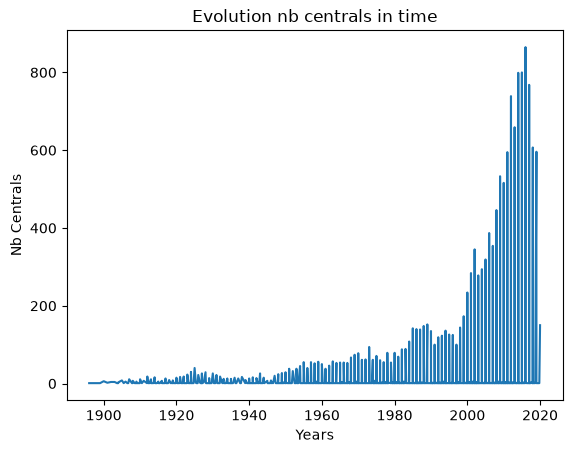

In [106]:
import matplotlib.pyplot as plt

plt.plot(unique_years, counts)
plt.xlabel("Years")
plt.ylabel("Nb Centrals")
plt.title("Evolution nb centrals in time")
plt.show()

## Advanced Visualization: